In [1]:
from matplotlib.ticker import LinearLocator
from jax import jit, random, vmap
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jax import config
import jax
import sys
from functools import partial

sys.path.append("../src")

jax.config.update("jax_platform_name", "cpu")

config.update("jax_enable_x64", True)

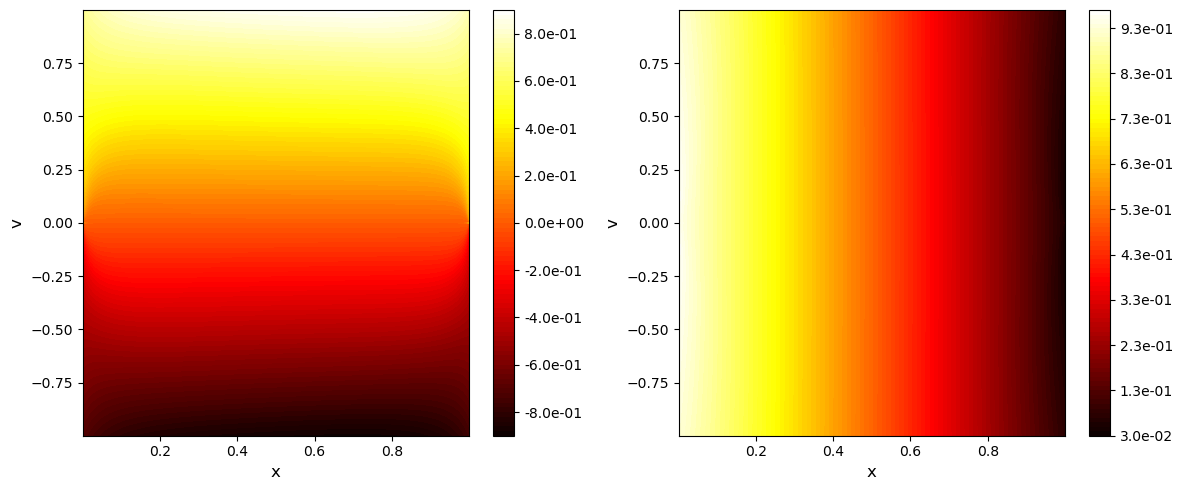

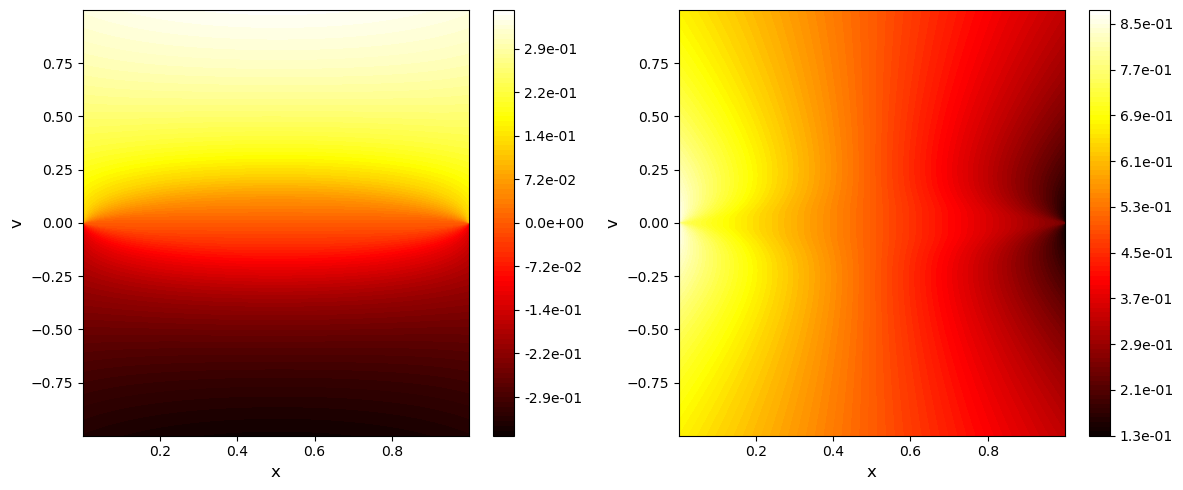

In [ ]:
# 分别画kn=0.1和kn=1.0的j、r分布（j左，r右），colorbar统一到e-2
kn_list = [1e-1, 1.0]
for kn_val in kn_list:
    data = np.load(f"../src/data/rte1d_ex2_ref_{kn_val:.1e}.npz")
    mesh_x = data["mesh_x"]  # shape (nx,)
    mesh_v = data["mesh_v"]  # shape (nv,)
    f = data["F"]  # shape (nx,nv)
    j = (f - f[::-1, :]) / (2 * kn_val)
    r = (f + f[::-1, :]) / 2
    X, V = np.meshgrid(mesh_x, mesh_v, indexing="ij")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    c1 = axes[0].contourf(X, V, j.T, 100, cmap="hot")
    fig.colorbar(c1, ax=axes[0], format="%.1e")
    # axes[0].set_title(f"Odd part j(x,v), kn={kn_val:.1e}", fontsize=14)
    axes[0].set_xlabel("x", fontsize=14)
    axes[0].set_ylabel("v", fontsize=14)
    c2 = axes[1].contourf(X, V, r.T, 100, cmap="hot")
    fig.colorbar(c2, ax=axes[1], format="%.1e")
    # axes[1].set_title(f"Even part r(x,v), kn={kn_val:.1e}", fontsize=14)
    axes[1].set_xlabel("x", fontsize=14)
    axes[1].set_ylabel("v", fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.close()

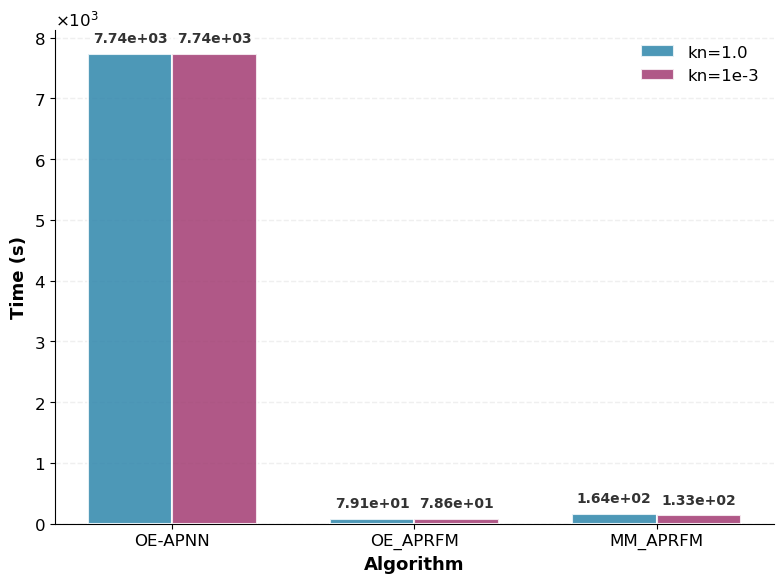

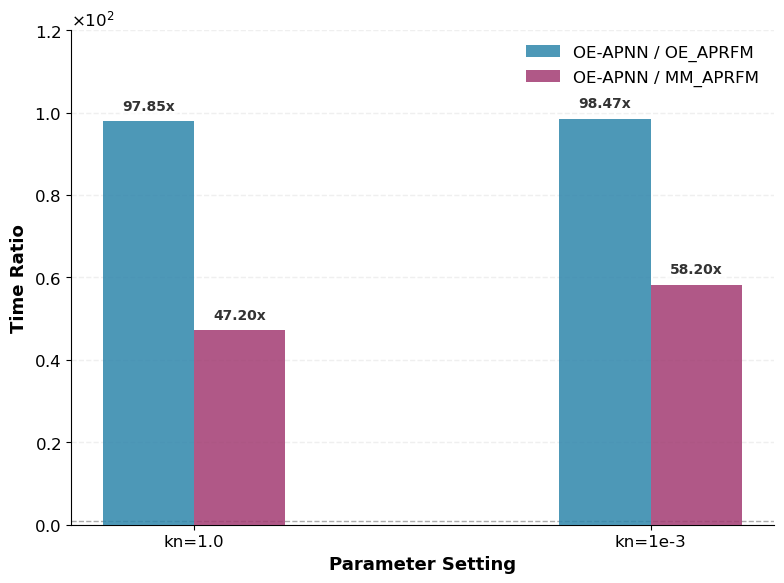

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from matplotlib.ticker import ScalarFormatter

# 设置字体和样式（适合论文发表）
plt.rcParams.update({
    "font.size": 12,
    "font.family": "DejaVu Sans",
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 14,
    "figure.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# 数据 - 运算时间（单位：秒，越低越好）
algorithms = ["OE-APNN", "OE_APRFM", "MM_APRFM"]
# 根据给定数据表：
# 		kn=1	kn=1e-3
# OE_APRFM	7.91E+01	7.86E+01
# MM_APRFM	1.64E+02	1.33E+02
# OE-APNN	7.74E+03	7.74E+03

# 注意这里的顺序与 algorithms 对应 [OE-APNN, OE_APRFM, MM_APRFM]
kn_1 = [7.74e3, 7.91e1, 1.64e2]  # kn = 1
kn_1em3 = [7.74e3, 7.86e1, 1.33e2]  # kn = 1e-3

# 1. 主要对比图（分组条形图）
fig, ax1 = plt.subplots(figsize=(8, 6))
x = np.arange(len(algorithms))
width = 0.35

bars1 = ax1.bar(
    x - width / 2,
    kn_1,
    width,
    label="kn=1.0",
    color="#2E86AB",
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)
bars2 = ax1.bar(
    x + width / 2,
    kn_1em3,
    width,
    label="kn=1e-3",
    color="#A23B72",
    alpha=0.85,
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)

ax1.set_xlabel("Algorithm", fontweight="bold")
ax1.set_ylabel("Time (s)", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(algorithms)
ax1.legend(frameon=False, loc="upper right")
ax1.grid(axis="y", alpha=0.2, linestyle="--", linewidth=1, zorder=0)
ax1.set_axisbelow(True)
ax1.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax1.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(
            f"{height:.2e}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color="#333",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.7,
                edgecolor="none",
            ),
        )

plt.tight_layout()
plt.show()

# 2. 时间比对比图（OE-APNN相对于OE_APRFM和MM_APRFM）
fig, ax2 = plt.subplots(figsize=(8, 6))
ratio_oe_aprfm = [kn_1[0] / kn_1[1], kn_1em3[0] / kn_1em3[1]]
ratio_mm_aprfm = [kn_1[0] / kn_1[2], kn_1em3[0] / kn_1em3[2]]

bar_width = 0.2
bar_x = np.arange(2)
bars_ratio1 = ax2.bar(
    bar_x - bar_width / 2,
    ratio_oe_aprfm,
    bar_width,
    label="OE-APNN / OE_APRFM",
    color="#2E86AB",
    alpha=0.85,
    zorder=3,
)
bars_ratio2 = ax2.bar(
    bar_x + bar_width / 2,
    ratio_mm_aprfm,
    bar_width,
    label="OE-APNN / MM_APRFM",
    color="#A23B72",
    alpha=0.85,
    zorder=3,
)

ax2.set_xlabel("Parameter Setting", fontweight="bold")
ax2.set_ylabel("Time Ratio", fontweight="bold")
ax2.set_xticks(bar_x)
ax2.set_xticklabels(["kn=1.0", "kn=1e-3"])
ax2.axhline(y=1, color="#888", linestyle="--", linewidth=1, alpha=0.7, zorder=1)
ax2.grid(axis="y", alpha=0.2, linestyle="--", linewidth=1, zorder=0)
ax2.set_axisbelow(True)
ax2.set_ylim(0, 120)
ax2.legend(frameon=False, loc="upper right")
ax2.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax2.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

for bars in [bars_ratio1, bars_ratio2]:
    for bar in bars:
        height = bar.get_height()
        ax2.annotate(
            f"{height:.2f}x",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color="#333",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.7,
                edgecolor="none",
            ),
        )

plt.tight_layout()
plt.show()

# # 3. 雷达图/蜘蛛网图 - 展示多维对比
# categories = ["kn=0.1", "kn=1.0", "Avg"]
# N = len(categories)
# apnn_values = [kn_01[0], kn_10[0], np.mean([kn_01[0], kn_10[0]])]
# oe_aprfm_values = [kn_01[1], kn_10[1], np.mean([kn_01[1], kn_10[1]])]
# mm_aprfm_values = [kn_01[2], kn_10[2], np.mean([kn_01[2], kn_10[2]])]

# max_val = max(max(apnn_values), max(oe_aprfm_values), max(mm_aprfm_values))
# apnn_norm = [1 - v / max_val for v in apnn_values]
# oe_aprfm_norm = [1 - v / max_val for v in oe_aprfm_values]
# mm_aprfm_norm = [1 - v / max_val for v in mm_aprfm_values]

# apnn_norm = apnn_norm + [apnn_norm[0]]
# oe_aprfm_norm = oe_aprfm_norm + [oe_aprfm_norm[0]]
# mm_aprfm_norm = mm_aprfm_norm + [mm_aprfm_norm[0]]
# angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
# angles += angles[:1]

# fig = plt.figure(figsize=(6, 5))
# ax3 = plt.subplot(111, polar=True)
# ax3.plot(
#     angles,
#     apnn_norm,
#     "o-",
#     linewidth=2,
#     label="OE-APNN",
#     color="#2E86AB",
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     zorder=3,
# )
# ax3.plot(
#     angles,
#     oe_aprfm_norm,
#     "s-",
#     linewidth=2,
#     label="OE_APRFM",
#     color="#A23B72",
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     zorder=2,
# )
# ax3.plot(
#     angles,
#     mm_aprfm_norm,
#     "^-",
#     linewidth=2,
#     label="MM_APRFM",
#     color="#F39C12",
#     markersize=8,
#     markerfacecolor="white",
#     markeredgewidth=2,
#     zorder=1,
# )
# ax3.fill(angles, apnn_norm, alpha=0.10, color="#2E86AB")
# ax3.fill(angles, oe_aprfm_norm, alpha=0.10, color="#A23B72")
# ax3.fill(angles, mm_aprfm_norm, alpha=0.10, color="#F39C12")

# ax3.set_theta_offset(np.pi / 2)
# ax3.set_theta_direction(-1)
# ax3.set_xticks(angles[:-1])
# ax3.set_xticklabels(categories)
# ax3.set_ylim(0, 1)
# ax3.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
# ax3.set_yticklabels(["20%", "40%", "60%", "80%", "100%"])
# ax3.grid(True, alpha=0.25)
# ax3.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1), frameon=False)

# plt.tight_layout()
# plt.show()

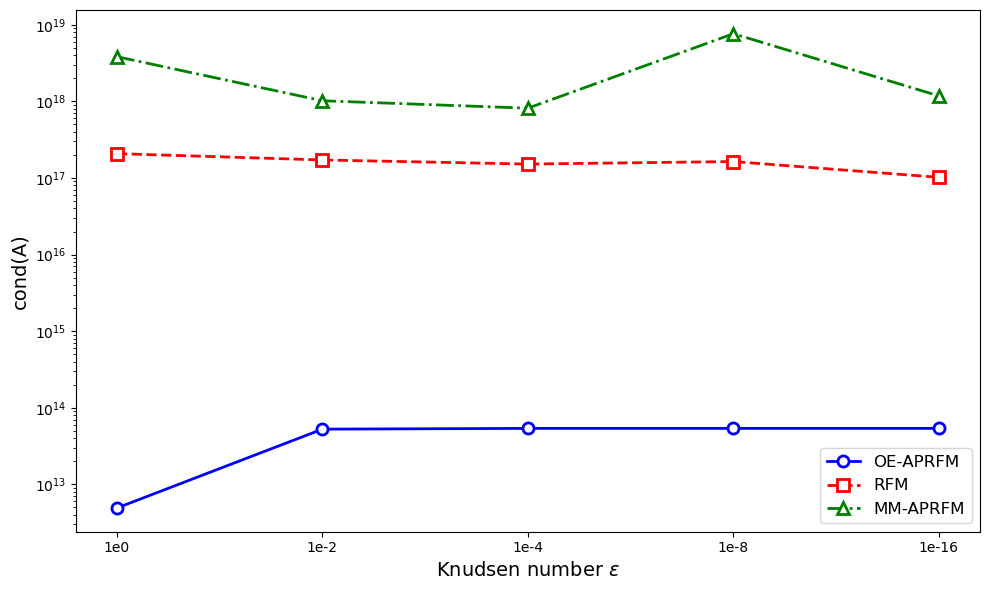

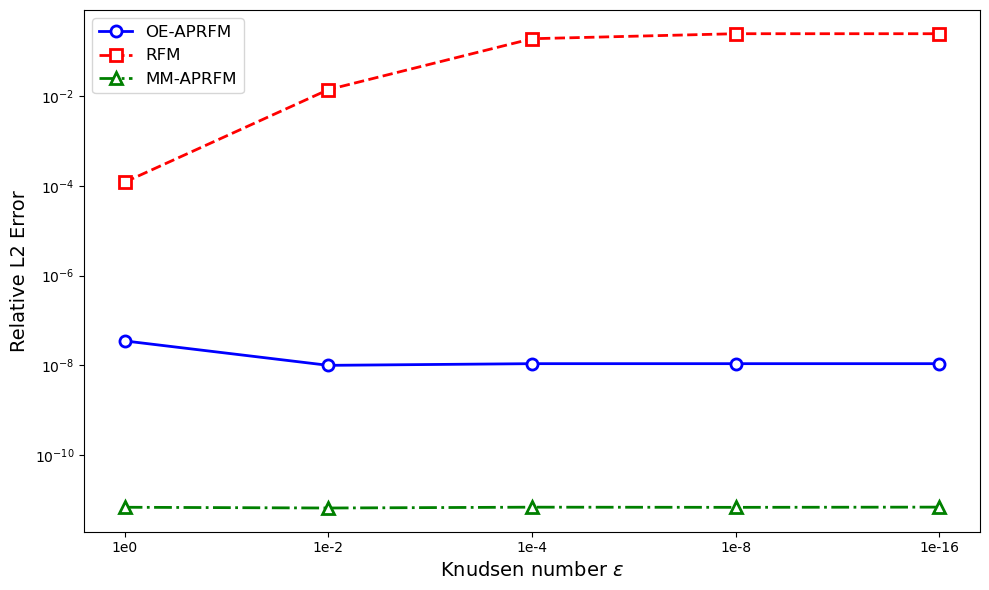

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
x_labels = ["1e0", "1e-2", "1e-4", "1e-8", "1e-16"]
x_values = [1, 1e-2, 1e-4, 1e-8, 1e-16]

# 计算对数坐标值用于均匀分布
log_x_values = np.linspace(1, 6, 5)  # 转换为对数坐标 [0, -2, -4, -8, -16]

# First dataset: cond(A) values for three methods
cond_data = {
    "OE-APRFM": [4.90e12, 5.25e13, 5.37e13, 5.37e13, 5.37e13],
    "RFM": [2.08e17, 1.72e17, 1.52e17, 1.64e17, 1.02e17],
    "MM-APRFM": [3.84e18, 1.02e18, 8.16e17, 7.66e18, 1.18e18],
}

# Second dataset: F-F_ref values for three methods
fref_data = {
    "OE-APRFM": [3.50e-08, 1.00e-08, 1.09e-08, 1.09e-08, 1.09e-08],
    "RFM": [1.20e-04, 1.38e-02, 1.88e-01, 2.43e-01, 2.43e-01],
    "MM-APRFM": [6.91e-12, 6.65e-12, 6.94e-12, 6.88e-12, 6.96e-12],
}

# Colors and markers for different methods
colors = {"OE-APRFM": "blue", "RFM": "red", "MM-APRFM": "green"}
markers = {"OE-APRFM": "o", "RFM": "s", "MM-APRFM": "^"}
line_styles = {"OE-APRFM": "-", "RFM": "--", "MM-APRFM": "-."}

# ========== FIGURE 1: cond(A) Plot with Uniformly Distributed Points ==========
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 6))

for method in cond_data.keys():
    ax1.semilogy(
        log_x_values,  # 使用对数坐标值
        cond_data[method],
        marker=markers[method],
        color=colors[method],
        linestyle=line_styles[method],
        label=method,
        linewidth=2,
        markersize=8,
        markerfacecolor="white",
        markeredgewidth=2,
    )

# 设置x轴
ax1.set_xlabel("Knudsen number $\epsilon$", fontsize=14)
ax1.set_ylabel("cond(A)", fontsize=14)
# ax1.grid(True, which="both", linestyle="--", alpha=0.6)
ax1.legend(fontsize=12)

# 设置x轴刻度和标签
ax1.set_xticks(log_x_values)
ax1.set_xticklabels(x_labels)

plt.tight_layout()
# plt.savefig("cond_A_comparison_uniform.png", dpi=300, bbox_inches="tight")
plt.show()

# ========== FIGURE 2: Relative L2 Error Plot with Uniformly Distributed Points ==========
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 6))

for method in fref_data.keys():
    ax2.semilogy(
        log_x_values,  # 使用对数坐标值
        fref_data[method],
        marker=markers[method],
        color=colors[method],
        linestyle=line_styles[method],
        label=method,
        linewidth=2,
        markersize=8,
        markerfacecolor="white",
        markeredgewidth=2,
    )

# 设置x轴
ax2.set_xlabel("Knudsen number $\epsilon$", fontsize=14)
ax2.set_ylabel("Relative L2 Error", fontsize=14)
# ax2.grid(True, which="both", linestyle="--", alpha=0.6)
ax2.legend(fontsize=12)

# 设置x轴刻度和标签
ax2.set_xticks(log_x_values)
ax2.set_xticklabels(x_labels)

plt.tight_layout()
# plt.savefig("relative_L2_error_comparison_uniform.png", dpi=300, bbox_inches="tight")
plt.show()
